The model simulates a bottom-up Private Equity ecosystem to map the mechanical emergence of the reverted J-curve.
It deploys an algebraic TVPI-estimator to identify the unobservable economic discount from public accounting data.
Ultimately, it proves how NAV staleness and selection bias cause observable metrics to severely overstate the true liquidity premium during market crashes.
# 1. Macro-Calibration & Parametrization
In this section, we define the simulation scale and inject empirical targets. 
The asset generation follows a Geometric Brownian Motion (GBM), while the accounting 
lag is strictly calibrated to the Brown, Ghysels & Gredil (2023) smoothing parameter ($\lambda = 0.50$). 
Market betas and volatilities are anchored to Damodaran's industry datasets.

In [1]:
# --- STEP 1: INPUT PARAMETERS ---
# Bottom-Up Company Monte Carlo Simulation
# Primary vs. Secondary PE Fund Comparison
# Quarterly NAV process based on Brown, Ghysels & Gredil (2023)


import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# 1. SIMULATION SCALE & TIME GRID

N_SIMULATIONS = 10000       # Monte Carlo iterations
RANDOM_SEED   = 42           # For reproducibility

PERIODS_PER_YEAR    = 4
fund_lifetime_years = 10
fund_lifetime_q     = fund_lifetime_years * PERIODS_PER_YEAR  # 40 quarters
investment_period_y = 5
investment_period_q = investment_period_y * PERIODS_PER_YEAR  # 20 quarters


# 2. GENERAL MARKET ASSUMPTIONS (Quarterly)

market_return_q_mean = 0.0194  # 1.94% expected quarterly return (8% annualized)
market_vol_q         = 0.0750  # 7.5% quarterly volatility (15% annualized)


# 3. FUND ARCHITECTURE

fund_size = 1.0  # Normalized committed capital


# 4. PRIMARY FUND: COMPANY-LEVEL ASSUMPTIONS
# calibration to the literature-supported range
mean_n_companies = 12        # Mean number of portfolio companies
sd_n_companies   = 4         # Std dev of portfolio size
min_n_companies  = 5         # Hard floor

# A. Deployment Timing (Front-loaded over 20 quarters)
# Simplified mapping representing: Y1: 25%, Y2: 30%, Y3: 25%, Y4: 15%, Y5: 5%
primary_deploy_weights_q = {}
for q in range(1, 21):
    if q <= 4:   weight = 0.25 / 4
    elif q <= 8: weight = 0.30 / 4
    elif q <= 12: weight = 0.25 / 4
    elif q <= 16: weight = 0.15 / 4
    else:         weight = 0.05 / 4
    primary_deploy_weights_q[q] = weight

# B. Holding Period (Exit Timing)
mean_holding_period_q = 20.0 # Mean 5 years
sd_holding_period_q   = 6.0  # Std dev 1.5 years
min_holding_period_q  = 8.0  # Hard floor: 2 years (no flip sales)


# 5. SECTOR ALLOCATIONS & PARAMETERS (Quarterly Converted)
# Calibrated for realistic downside risk and upside potential across sectors
# from Cambridge Associates PE report (2024)  
sector_weights = {
    'Information Technology': 0.358, 'Healthcare': 0.14, 'Consumer Discretionary': 0.106,
    'Industrials': 0.152, 'Financials': 0.093, 'Communication Services': 0.056,
    'Others & Real Estate': 0.095
}
# from Damodaran (Jan 2026) and BGG (2023), quarterlyized for simulation
sector_params = {
    'Information Technology':             
        {'g_TAM_q': 0.027, 'alpha_q': 0.0170, 'sigma_idio_q': 0.273},
        # High growth, extreme volatility (freq. bankruptcies, high unicorns)
        
    'Healthcare':             
        {'g_TAM_q': 0.031, 'alpha_q': 0.0186, 'sigma_idio_q': 0.293},
        # suited for LBO debt servicing (drugs (biotech/pharma) are not included from Damodaran's study)
        
    'Consumer Discretionary': 
        {'g_TAM_q': 0.020, 'alpha_q': 0.0178, 'sigma_idio_q': 0.234},
        # Cyclical risk, highly sensitive to economic downturns
        
    'Financials':     
        {'g_TAM_q': 0.021, 'alpha_q': 0.0153, 'sigma_idio_q': 0.144},
        # Leverage increases downside risk
        
    'Industrials':            
        {'g_TAM_q': 0.021, 'alpha_q': 0.0186, 'sigma_idio_q': 0.246},
        # Capital intensive, but tangible assets provide a floor
        
    'Communication Services':         
        {'g_TAM_q': 0.034, 'alpha_q': 0.0153, 'sigma_idio_q': 0.265},
        # Regulated cash flows, highly stable
        
    'Others & Real Estate':       
        {'g_TAM_q': 0.016, 'alpha_q': 0.0145, 'sigma_idio_q': 0.226},
        # Most defensive sector. Lowest growth, lowest volatility.
}


# 6. SECONDARY FUND: TRANSACTION PARAMETERS

# A. Entry Timing
sec_entry_mean_q = 20.0  # Mean Quarter 20 (Year 5)
sec_entry_sd_q   = 4.0   # Std dev of 4 quarters
sec_entry_min_q  = 16.0  # Hard floor: Quarter 16 (Year 4)
sec_entry_max_q  = 36.0  # Hard ceiling: Quarter 36 (Year 9)

# 7. NAV REPORTING & SMOOTHING (Brown et al. 2023)

lambda_q    = 0.52  # GP appraisal smoothing weight (Quarterly approx of BGG 0.951 weekly: 0.951^13 = 0.52)
sigma_noise = 0.05  # Random NAV reporting noise std dev (conservative choice)


#  8. SECTOR MARKET BETAS  (Damodaran Jan 2026, unlevered -> re-levered)
BUYOUT_DE = 1.0          # buyout debt/equity (debt 50% of EV) - from PitchBook data, 2024
TAX_RATE  = 0.25         # corporate tax rate (Spain)
relever   = 1 + (1 - TAX_RATE) * BUYOUT_DE        # Hamada equation 
# Unlevered betas (cash-corrected) from Damodaran (Jan 2026), re-levered for buyout capital structure
sector_unlevered_beta = {
    'Information Technology': 1.17, 'Healthcare': 0.85, 'Consumer Discretionary': 0.88,
    'Financials': 0.44, 'Industrials': 0.93,
    'Communication Services': 0.81, 'Others & Real Estate': 0.64,
}
for s in sector_params:
    sector_params[s]['beta'] = sector_unlevered_beta[s] * relever


#  9. FUND ECONOMICS: management fee & carried interest
MGMT_FEE_ANNUAL = 0.02   # 2% per annum on committed, charged while the fund is active
CARRY_RATE      = 0.20   # 20% carried interest
HURDLE_ANNUAL   = 0.08   # 8% preferred return (carry only if the fund clears it)


# 10. TWO-CHANNEL SECONDARY DISCOUNT (from Jefferies Global Secondary Market Review H1 2025)
frac_opportunistic = 0.50   # share of secondaries that are opportunistic 
# Opportunistic (buyer wants a healthy stake): low discount
opp_disc_mean, opp_disc_sd, opp_disc_min, opp_disc_max = 0.05, 0.02, 0.02, 0.10 # mean calibrated on Jefferies 2025 report
# Liquidity-driven (forced/distressed): discount rises as NAV health falls (Nadauld et. al. 2021/Jefferies report)
liq_disc_base, liq_disc_sens          = 0.16, 0.50 
liq_disc_min,  liq_disc_max           = 0.12, 0.40 
health_ref                            = 1.0   # reported TVPI-to-date reference (1.0 = at cost)

# VALIDATION DASHBOARD
assert abs(sum(primary_deploy_weights_q.values()) - 1.0) < 1e-9, "Deployment weights must sum to 1"
assert abs(sum(sector_weights.values()) - 1.0) < 1e-9, "Sector weights must sum to 1"
assert min_n_companies >= 1
assert sec_entry_min_q < sec_entry_max_q
assert opp_disc_min < opp_disc_max
assert liq_disc_min < liq_disc_max
assert 0 < lambda_q < 1

print(" STEP 1: PARAMETERS LOADED — Stochastic Model, BGG-calibrated")
print(f"  Simulations:           {N_SIMULATIONS:,}")
print(f"  Time grid:             {fund_lifetime_q} quarters ({fund_lifetime_years} years)")
print(f"  Secondary entry:       Endogenous (Bounds: Q{int(sec_entry_min_q)} to Q{int(sec_entry_max_q)})")
print(f"  Secondary pricing:     Two-Channel (Opp: {opp_disc_mean*100:.0f}% | Liq base: {liq_disc_base*100:.0f}%)")


 STEP 1: PARAMETERS LOADED — Stochastic Model, BGG-calibrated
  Simulations:           10,000
  Time grid:             40 quarters (10 years)
  Secondary entry:       Endogenous (Bounds: Q16 to Q36)
  Secondary pricing:     Two-Channel (Opp: 5% | Liq base: 16%)


# 2. The Simulation Engine (Systemic Macro & Micro-Dynamics)
This core engine introduces a "Flattened Cohort Architecture". To accurately model systemic 
risk and avoid falsely narrow confidence intervals, 10,000 funds are generated within 
50 independent global macro-economies. 
The cash flow mechanics enforce an exact Sequential European Waterfall (100% GP Catch-Up), 
transitioning management fees from committed to active capital.

In [2]:
# --- STEP 2: ENGINE (market factor + fees/carry + 2-channel secondary) ---

import time, numpy as np
print("Step 2: Bottom-Up Simulation Engine (full economics)")
t0 = time.time()
N, Q = N_SIMULATIONS, fund_lifetime_q

prim_calls_arr=np.zeros((N,Q+1)); prim_dists_arr=np.zeros((N,Q+1))
true_nav_arr=np.zeros((N,Q+1));   rep_nav_arr=np.zeros((N,Q+1))
r_true_period_arr=np.zeros((N,Q+1)); r_bar_period_arr=np.zeros((N,Q+1))
sec_cf_arr=np.zeros((N,Q+1))
sec_metadata=np.zeros((N,4))          # [entry_q, discount, channel, health]
market_index_arr=np.zeros((N,Q+1))    # per-fund market path (for PME)
mgmt_fee_arr=np.zeros((N,Q+1))        # quarterly management fees
net_dist_arr=np.zeros((N,Q+1))        # distributions net of carry
lp_net_cf_arr=np.zeros((N,Q+1))       # LP net cash flow (after fees & carry)
carry_arr=np.zeros(N)                 # total carry per fund
sec_decon_arr = np.zeros(N) # per-fund secondary deconvolution factor (for diagnostics)

sector_names=list(sector_weights.keys()); sector_probs=np.array(list(sector_weights.values()))
deploy_qs=np.array(list(primary_deploy_weights_q.keys())); deploy_probs=np.array(list(primary_deploy_weights_q.values()))
rng=np.random.default_rng(RANDOM_SEED)
fee_q   = MGMT_FEE_ANNUAL/PERIODS_PER_YEAR*fund_size                 
fv_factor = (1+HURDLE_ANNUAL)**((Q-np.arange(Q+1))/PERIODS_PER_YEAR) #FV-to-end factors at 8%

# FLATTENED COHORT ARCHITECTURE (50 ECONOMIES) ---

# 1. DEFINE STRATEGIC MACRO COHORTS
M_MACRO_PATHS = 50                              # 50 independent macroeconomic paths
N_FUNDS_PER_MACRO = N // M_MACRO_PATHS          # 200 funds in each economy (50*200=10,000)

# 2. PRE-GENERATE THE 50 GLOBAL MACRO ECONOMIES (Array 2D: 50 x 41)
global_market_shocks = rng.normal(0, 1, (M_MACRO_PATHS, Q+1))
global_market_indices = np.zeros((M_MACRO_PATHS, Q+1))

for m in range(M_MACRO_PATHS):
    mkt_shock = market_vol_q * global_market_shocks[m]
    mkt_logret = np.log(1 + market_return_q_mean) - 0.5 * market_vol_q**2 + mkt_shock
    global_market_indices[m] = np.concatenate([[1.0], np.exp(np.cumsum(mkt_logret[1:]))])

# 3. MAIN SIMULATION ENGINE
for sim in range(N):
    if (sim+1)%2000==0: print(f"  ... {sim+1:,}/{N:,}")
    
    # Identify which of the 50 economies this specific fund belongs to
    macro_idx = sim // N_FUNDS_PER_MACRO
    
    # Extract the specific market for this fund (becomes its global_market_index)
    global_market_index = global_market_indices[macro_idx]
    market_index_arr[sim] = global_market_index
    
    # The mkt_shock for company calculation is the one from ITS specific economy
    mkt_shock = market_vol_q * global_market_shocks[macro_idx]
    
    # n_companies=int(max(min_n_companies,np.round(rng.normal... ecc.))
    n_companies=int(max(min_n_companies,np.round(rng.normal(mean_n_companies,sd_n_companies))))
    capital_per_company=fund_size/n_companies
    fund_true_nav=np.zeros(Q+1)
    
    # Track the Net Invested Capital for the fee step-down
    active_cost = np.zeros(Q+1) 

    for c in range(n_companies):
        params=sector_params[rng.choice(sector_names,p=sector_probs)]
        invest_q=int(rng.choice(deploy_qs,p=deploy_probs))
        hold_q=int(max(min_holding_period_q,np.round(rng.normal(mean_holding_period_q,sd_holding_period_q))))
        exit_q=int(min(Q,invest_q+hold_q)); periods=exit_q-invest_q
        if periods<=0: continue
        drift = params['g_TAM_q'] + params['alpha_q']
        sigma=params['sigma_idio_q']; beta=params['beta']
        idio_resid=np.sqrt(max(0.0,sigma**2-beta**2*market_vol_q**2))
        window=mkt_shock[invest_q+1:exit_q+1]
        log_returns=drift-0.5*sigma**2+beta*window+rng.normal(0,idio_resid,periods)
        values=capital_per_company*np.exp(np.cumsum(log_returns))
        
        prim_calls_arr[sim,invest_q]-=capital_per_company
        fund_true_nav[invest_q]+=capital_per_company
        
        if periods>1: 
            fund_true_nav[invest_q+1:exit_q]+=values[:-1]
            active_cost[invest_q+1:exit_q]+=capital_per_company # Sum the company cost for the quarters it is active
            
        prim_dists_arr[sim,exit_q]+=values[-1]
    
    true_nav_arr[sim]=fund_true_nav

    # BGG smoothing (asset-level, gross — unchanged)
    fund_rep_nav=np.zeros(Q+1); r_cum=0.0; r_bar_cum=0.0
    for t in range(1,Q+1):
        denom=fund_true_nav[t-1]; numer=fund_true_nav[t]+prim_dists_arr[sim,t]+prim_calls_arr[sim,t]
        r_t=np.log(numer/denom) if (denom>1e-9 and numer>1e-9) else 0.0
        r_cum_new=r_cum+r_t; r_bar_cum_new=lambda_q*r_bar_cum+(1-lambda_q)*r_cum_new
        r_true_period_arr[sim,t]=r_t; r_bar_period_arr[sim,t]=r_bar_cum_new-r_bar_cum
        if fund_true_nav[t]>1e-9: fund_rep_nav[t]=fund_true_nav[t]*np.exp((r_bar_cum_new-r_cum_new)+rng.normal(0,sigma_noise))
        r_cum=r_cum_new; r_bar_cum=r_bar_cum_new
    rep_nav_arr[sim]=fund_rep_nav

   
    # --- FEES + CARRY OVERLAY (European Waterfall, 100% Catch-up & Step-Down) ---
    
    invest_calls = -prim_calls_arr[sim]
    
    # 1. Management Fees: 2% Committed (Y1-Y5), 2% Net Invested (Y6-Y10)
    fees = np.zeros(Q+1)
    inv_period = int(5 * PERIODS_PER_YEAR) # 20 trimestri
    
    for t in range(1, Q+1):
        if t <= inv_period:
            fees[t] = (MGMT_FEE_ANNUAL / PERIODS_PER_YEAR) * fund_size
        else:
            fees[t] = (MGMT_FEE_ANNUAL / PERIODS_PER_YEAR) * active_cost[t]
            
    # Zero fees if empty fund (NAV and active cost both near zero)
    fees = np.where((fund_true_nav > 1e-9) | (active_cost > 1e-9), fees, 0.0)
    fees[0] = 0.0
    mgmt_fee_arr[sim] = fees
    contrib = invest_calls + fees
    
    gross_dist = prim_dists_arr[sim].copy()
    terminal = true_nav_arr[sim, -1]
    
# 2. EUROPEAN WATERFALL DYNAMICS (Sequential Cash Flow Distribution)
    lp_unreturned = 0.0
    lp_total_tier1 = 0.0
    total_contrib_so_far = 0.0
    gp_total_catchup = 0.0
    gp_total_8020 = 0.0
    
    net_dist = np.zeros(Q+1) # Array FOR EFFECTIVE LP'S DISTRIBUTIONS (AFTER FEES & CARRY)
    
    for t in range(Q+1):
        # Sequential capitalisation of unreturned capital + preferred return (Hurdle): QUARTERLY
        lp_unreturned = lp_unreturned * (1 + HURDLE_ANNUAL / PERIODS_PER_YEAR)
        lp_unreturned += contrib[t]
        total_contrib_so_far += contrib[t]
        
        d_t = gross_dist[t]
        if t == Q: d_t += terminal
        
        lp_cf_t = 0.0  # How much the LP actually receives in THIS specific quarter (after fees and carry)
        
        if d_t > 0:
            # TIER 1: 100% LP (Return of Capital + 8% Hurdle)
            pay_tier1 = min(d_t, lp_unreturned)
            if pay_tier1 > 0:
                lp_unreturned -= pay_tier1
                d_t -= pay_tier1
                lp_total_tier1 += pay_tier1
                lp_cf_t += pay_tier1
                
            # TIER 2: 100% GP Catch-Up
            if lp_unreturned <= 1e-9 and d_t > 0:
                lp_unreturned = 0.0 # reset float rounding
                pref_generated = lp_total_tier1 - total_contrib_so_far
                gp_catchup_target = (CARRY_RATE / (1.0 - CARRY_RATE)) * pref_generated
                catchup_deficit = max(0.0, gp_catchup_target - gp_total_catchup)
                
                pay_tier2 = min(d_t, catchup_deficit)
                gp_total_catchup += pay_tier2
                d_t -= pay_tier2
                
                # TIER 3: 80/20 Split (LP takes the remaining distribution after catch-up, but GP takes 20% of it)
                if d_t > 0:
                    pay_tier3_lp = (1.0 - CARRY_RATE) * d_t
                    gp_total_8020 += (CARRY_RATE * d_t) # track per diagnostica
                    lp_cf_t += pay_tier3_lp
                    
        # record the EXACT net quarterly cash flow to the LP (after fees and carry)
        net_dist[t] = lp_cf_t
        
    carry_arr[sim] = gp_total_catchup + gp_total_8020
    net_dist_arr[sim] = net_dist
    lp_net_cf_arr[sim] = -invest_calls - fees + net_dist

# NOTE:
# 3. Endogenous Secondary Entry Mechanism
# Secondary transactions are not modeled as purely exogenous random events. 
# Sale timing and discount depth are endogenously coupled to the macro-regime. 
# During simulated market crashes, LP distress surges (Denominator Effect), 
# mechanically clustering funds into the deep-discount 'Liquidity' channel 
# (consistent with Nadauld et al., 2019)

# SYSTEMIC TWO-CHANNEL SECONDARY (Macro-dependent Denominator Effect)
    # ENDOGENOUS SALE TIMING (Clustering in bad states)
    # Calculate the sale probability for each quarter in the active window (Q16 - Q36)
    window_qs = np.arange(int(sec_entry_min_q), int(sec_entry_max_q) + 1)   # integer grid
    base_probs = np.exp(-0.5 * ((window_qs - sec_entry_mean_q) / sec_entry_sd_q)**2) # Normal distributions as baseline 
    
    # Stress multiplier: if the global economy performs poorly, the probability of sale spikes
    stress_multipliers = np.ones_like(window_qs, dtype=float)
    for idx, q in enumerate(window_qs):
        macro_trailing_1y = market_index_arr[sim, q] / market_index_arr[sim, max(0, q-4)]
        if macro_trailing_1y < 0.90:
            stress_multipliers[idx] = 3.5 # Sales volume triples/quadruples during a crash
            
    adjusted_probs = base_probs * stress_multipliers
    adjusted_probs /= adjusted_probs.sum() # Normalization to 1.0
    
    entry_q = int(rng.choice(window_qs, p=adjusted_probs))
    
    # 1. Macro State: Trailing 1-year stock market return
    macro_trailing_1y = global_market_index[entry_q] / global_market_index[max(0, entry_q - 4)]
    
    # 2. Denominator Effect Clustering: If the market drops >10%, all pension funds sell
    if macro_trailing_1y < 0.90:
        prob_opportunistic = 0.15 # 85% Forced Selling
    else:
        prob_opportunistic = frac_opportunistic # 50% baseline in calm markets

    health = (gross_dist[:entry_q+1].sum() + fund_rep_nav[entry_q]) / max(invest_calls[:entry_q+1].sum(), 1e-9)
    
    if rng.random() < prob_opportunistic:
        discount = float(np.clip(rng.normal(opp_disc_mean, opp_disc_sd), opp_disc_min, opp_disc_max))
        channel = 0
    else:
        discount = float(np.clip(liq_disc_base + liq_disc_sens * max(0.0, health_ref - health), liq_disc_min, liq_disc_max))
        channel = 1
    # economic discount = haircut to TRUE value, not to the stale reported mark
    sec_decon_arr[sim] = 1 - (fund_rep_nav[entry_q] * (1 - discount)) / max(fund_true_nav[entry_q], 1e-9)    
        
    sec_metadata[sim] = [entry_q, discount, channel, health]
    sec_cf_arr[sim, entry_q] -= fund_rep_nav[entry_q] * (1 - discount)
    if entry_q < Q: 
        sec_cf_arr[sim, entry_q+1:] += lp_net_cf_arr[sim, entry_q+1:]

print(f"Done in {time.time()-t0:.1f}s")

# D. COMPLETION

elapsed = time.time() - t0
print("=" * 65)
print(" STEP 2 COMPLETE: DATA MATRICES GENERATED")
print("=" * 65)
print(f"  Total compute time:      {elapsed:.1f} seconds")
print(f"  Primary calls shape:     {prim_calls_arr.shape}")
print(f"  Primary dists shape:     {prim_dists_arr.shape}")
print(f"  True NAV shape:          {true_nav_arr.shape}")
print(f"  Reported NAV shape:      {rep_nav_arr.shape}")
print(f"  Secondary CF shape:      {sec_cf_arr.shape}")
print("=" * 65)


# E. VALIDATION DIAGNOSTICS


# i) BGG smoothing validation: autocorrelation of periodic log-returns
def autocorr1_panel(series, q_lo=4, q_hi=37): # we are looking only between the second and nineth year
    """Per-fund lag-1 autocorrelation, restricted to the mid-fund active window."""
    rho = []
    for s in range(series.shape[0]): # 10000
        r = series[s, q_lo:q_hi] 
        if r.std() > 1e-9 and len(r) > 4: # Company is active and at least 4 quarters
            x = r[:-1] - r[:-1].mean() # array of past returns (x Pearson correlation)
            y = r[1:]  - r[1:].mean() # array of today's returns (x Pearson correlation)
            denom = np.sqrt((x * x).sum() * (y * y).sum())  
            if denom > 0:
                rho.append((x * y).sum() / denom) # Pearson corrrelation
    return np.array(rho) # target: 0 for reality and around 0.41 for Smoothing Accountability (BGG)

rho_true = autocorr1_panel(r_true_period_arr)
rho_bar  = autocorr1_panel(r_bar_period_arr)

print(f"\n  Smoothing validation — periodic log-return autocorrelation (Q4..Q36):")
print(f"    r_t (true, i.i.d. by construction):  rho_1 = {rho_true.mean():+.3f}   (target ~0)")
print(f"    r_bar_t (smoothed):                  rho_1 = {rho_bar.mean():+.3f}   (target ~ BGG empirical 0.41)")

# ii) Year-end averages: it should show classic primary-fund pattern
mean_true       = true_nav_arr.mean(axis=0)
mean_rep        = rep_nav_arr.mean(axis=0)
mean_cum_called = prim_calls_arr.cumsum(axis=1).mean(axis=0) # 1st axis = time; 0 axis = funds
mean_cum_dist   = prim_dists_arr.cumsum(axis=1).mean(axis=0)

print(f"\n  Year-end averages:")
print(f"  {'Y':>3} {'NAV_true':>10} {'NAV_rep':>10} {'Cum.Called':>12} {'Cum.Dist':>10}")
for y in [0, 1, 2, 3, 5, 7, 10]: # years
    q = y * 4 # quarter
    print(f"  {y:>3} {mean_true[q]:>10.4f} {mean_rep[q]:>10.4f} "
          f"{-mean_cum_called[q]:>12.4f} {mean_cum_dist[q]:>10.4f}")

# iii) Headline multiples
final_value  = prim_dists_arr.sum(axis=1) + true_nav_arr[:, -1] # sum of all the distributions -> if there is still at the end of year 10 an unsold fund value, it is added here
final_called = -prim_calls_arr.sum(axis=1)
TVPI         = final_value / final_called

print(f"\n  Terminal TVPI: mean {TVPI.mean():.2f}x, median {np.median(TVPI):.2f}x, "
      f"P10 {np.percentile(TVPI, 10):.2f}x, P90 {np.percentile(TVPI, 90):.2f}x")

Step 2: Bottom-Up Simulation Engine (full economics)
  ... 2,000/10,000
  ... 4,000/10,000
  ... 6,000/10,000
  ... 8,000/10,000
  ... 10,000/10,000
Done in 31.2s
 STEP 2 COMPLETE: DATA MATRICES GENERATED
  Total compute time:      31.2 seconds
  Primary calls shape:     (10000, 41)
  Primary dists shape:     (10000, 41)
  True NAV shape:          (10000, 41)
  Reported NAV shape:      (10000, 41)
  Secondary CF shape:      (10000, 41)

  Smoothing validation — periodic log-return autocorrelation (Q4..Q36):
    r_t (true, i.i.d. by construction):  rho_1 = -0.009   (target ~0)
    r_bar_t (smoothed):                  rho_1 = +0.457   (target ~ BGG empirical 0.41)

  Year-end averages:
    Y   NAV_true    NAV_rep   Cum.Called   Cum.Dist
    0     0.0000     0.0000      -0.0000     0.0000
    1     0.2674     0.2609       0.2519     0.0000
    2     0.6070     0.5883       0.5500     0.0000
    3     0.9256     0.8953       0.7984     0.0173
    5     1.2085     1.1595       1.0000     0.

# 4. Empirical Validation (Moment-Matching)
Before testing our hypotheses, we must prove the model is not overfitted. 
This table demonstrates that our micro-parameters organically reproduce complex, 
non-targeted macroeconomic realities (e.g., net TVPI ~1.50x, KS-PME ~1.0x, and 
blended secondary discounts ~13%).

In [3]:
# Secondary fund diagnostics: staleness, discount decomposition, and macro clustering
eq    = sec_metadata[:,0].astype(int)
stale = rep_nav_arr[np.arange(N), eq] / np.maximum(true_nav_arr[np.arange(N), eq], 1e-9)
d_rep, d_eco = sec_metadata[:,1], sec_decon_arr
tr1y = np.array([market_index_arr[i, q] / market_index_arr[i, max(0, q-4)] for i, q in enumerate(eq)])
crash = tr1y < 0.90
print(f"staleness rep/true: median {np.median(stale):.3f}")
print(f"d_reported {d_rep.mean():.3f} | d_economic {d_eco.mean():.3f} | wedge {(d_rep-d_eco).mean():+.3f}")
print(f"wedge  crash {(d_rep-d_eco)[crash].mean():+.3f} | calm {(d_rep-d_eco)[~crash].mean():+.3f}")

# an estimator recovering the reported discount (of this model and Nadauld's) overstates the true liquidity premium precisely in the forced-selling regime.

# --- ALPHA VALIDATION (Direct Alpha, Gredil-Griffiths-Stucke) ---
# Emergent validation moment: gross & net alpha vs. the deal-level
# and fund-level buyout literature.
#   - Gross anchor:  Buchner (2016): 7.0% p.a. (deal-level, before fees)
#   - Net anchors:   Buchner (2016, net): 1.0% p.a.
#                    Brown, Goncalves & Hu (2024): 2.5% p.a. (asset-class)
# Alpha is NOT calibrated to these values: it emerges from sector-level
# operational alphas (anchored to Buchner) run through the full waterfall.
import numpy as np

PPY = PERIODS_PER_YEAR
Q   = fund_lifetime_q
N   = N_SIMULATIONS

# ---- Scalar IRR via bisection (robust, no external dependency) -----------
def _irr_scalar(cf, lo=-0.99, hi=2.0, n_iter=300):
    """Quarterly IRR of a single cash-flow vector. NaN if no sign change."""
    powers = np.arange(len(cf))
    f = lambda r: (cf / (1.0 + r) ** powers).sum()
    if np.sign(f(lo)) == np.sign(f(hi)):
        return np.nan
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        if f(mid) > 0:   # NPV decreasing in rate
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

# ---- Direct Alpha core ------ 
# Discount every cash flow by the realised public-market path of its own
# economy, then take the IRR of the PME-discounted stream. That IRR is the
# annualised excess return over the public market = Direct Alpha.
disc = 1.0 / market_index_arr     # per-fund discount-factor path

def _direct_alpha(cf_matrix):
    """Returns (pooled_annual, per_fund_median_annual, per_fund_mean_annual)."""
    cf_pme = cf_matrix * disc
    # Pooled: aggregate discounted flows across all funds, then one IRR
    pooled_q = _irr_scalar(cf_pme.sum(axis=0))
    pooled_a = (1 + pooled_q) ** PPY - 1
    # Per-fund: one IRR per fund, then summarise
    per = []
    for i in range(N):
        q = _irr_scalar(cf_pme[i, :Q + 1])
        if np.isfinite(q):
            per.append((1 + q) ** PPY - 1)
    per = np.array(per)
    return pooled_a, np.nanmedian(per), np.nanmean(per), len(per)

# ---- Build the two cash-flow streams ------
# GROSS: capital calls (neg) + gross distributions (pos) + terminal true NAV.
gross_cf = prim_calls_arr + prim_dists_arr
gross_cf[:, Q] += true_nav_arr[:, Q]

# NET: LP net cash flow already includes -calls - fees + net_dist (after carry).
# Add terminal NAV (residual value at liquidation).
net_cf = lp_net_cf_arr.copy()
net_cf[:, Q] += true_nav_arr[:, Q]

# ---- Compute -------------
g_pool, g_med, g_mean, _ = _direct_alpha(gross_cf)
n_pool, n_med, n_mean, n_ok = _direct_alpha(net_cf)

# Plain pooled IRRs for context (not excess)
gross_irr = (1 + _irr_scalar(gross_cf.sum(axis=0))) ** PPY - 1
net_irr   = (1 + _irr_scalar(net_cf.sum(axis=0)))   ** PPY - 1

# Gross -> net compression (fee + carry drag on alpha)
compression_pool = (g_pool - n_pool) * 100
compression_med  = (g_med  - n_med)  * 100

# ---- Report -------
print("=" * 64)
print(" ALPHA VALIDATION — Direct Alpha (Gredil-Griffiths-Stucke)")
print("=" * 64)
print(f"  Pooled gross IRR:        {gross_irr*100:+6.2f}% p.a.")
print(f"  Pooled net IRR:          {net_irr*100:+6.2f}% p.a.")
print("-" * 64)
print(f"  GROSS Direct Alpha")
print(f"     pooled:               {g_pool*100:+6.2f}%   (Buchner 2016 gross: ~7.0%)")
print(f"     per-fund median:      {g_med*100:+6.2f}%")
print(f"     per-fund mean:        {g_mean*100:+6.2f}%")
print("-" * 64)
print(f"  NET Direct Alpha   (n={n_ok})")
print(f"     pooled:               {n_pool*100:+6.2f}%   (Brown-Goncalves-Hu 2024: 2.5%)")
print(f"     per-fund median:      {n_med*100:+6.2f}%   (Buchner 2016 net: ~1.0%)")
print(f"     per-fund mean:        {n_mean*100:+6.2f}%")
print("-" * 64)
print(f"  Gross->Net compression:  {compression_pool:.1f}pp (pooled) / "
      f"{compression_med:.1f}pp (median)")
print(f"     (Buchner fee+carry drag benchmark: ~6pp; 7.0% -> 1.0%)")
print("-" * 64)

# ---- Pass/fail flags (emergent-moment checks) ----
gross_ok = 5.0 <= g_pool*100 <= 9.0          # within Buchner / Franzoni range
net_ok   = 0.5 <= n_pool*100 <= 4.5          # within papers net bracket
print(f"  [CHECK] gross alpha in [5%, 9%] literature range:  {'PASS' if gross_ok else 'REVIEW'}")
print(f"  [CHECK] net alpha   in [0.5%, 4.5%] lit bracket:   {'PASS' if net_ok else 'REVIEW'}")
print("=" * 64)

staleness rep/true: median 0.984
d_reported 0.134 | d_economic 0.147 | wedge -0.014
wedge  crash +0.054 | calm -0.043
 ALPHA VALIDATION — Direct Alpha (Gredil-Griffiths-Stucke)
  Pooled gross IRR:        +16.35% p.a.
  Pooled net IRR:          +11.97% p.a.
----------------------------------------------------------------
  GROSS Direct Alpha
     pooled:                +7.54%   (Buchner 2016 gross: ~7.0%)
     per-fund median:       +5.24%
     per-fund mean:         +5.95%
----------------------------------------------------------------
  NET Direct Alpha   (n=10000)
     pooled:                +3.63%   (Brown-Goncalves-Hu 2024: 2.5%)
     per-fund median:       +1.99%   (Buchner 2016 net: ~1.0%)
     per-fund mean:         +2.34%
----------------------------------------------------------------
  Gross->Net compression:  3.9pp (pooled) / 3.3pp (median)
     (Buchner fee+carry drag benchmark: ~6pp; 7.0% -> 1.0%)
----------------------------------------------------------------
  [CHECK] 

In [4]:
# --- STEP 3: PERFORMANCE METRICS (IRR / TVPI / DPI) ---
# Per-fund metrics, averaged across funds (LP-experience IRR).
# Primary: by fund age.  Secondary: by buyer age AND calendar quarter.
# TVPI/IRR computed at both reported and true NAV marks.


import numpy as np
import warnings 

# --- Vectorized quarterly IRR via bisection (matches numpy_financial) ---
def irr_quarterly_vec(cf, lo=-0.9999, hi=10.0, n_iter=200):
    """cf: [n_funds, n_periods] quarterly cash flows. Returns quarterly IRR per fund."""
    cf = np.asarray(cf, dtype=float)
    powers = np.arange(cf.shape[1])
    lo_a = np.full(cf.shape[0], lo)
    hi_a = np.full(cf.shape[0], hi)
    def npv(rate):
        return (cf / (1.0 + rate[:, None]) ** powers[None, :]).sum(axis=1)
    bracketed = np.sign(npv(lo_a)) != np.sign(npv(hi_a))  # IRR exists only if NPV changes sign
    for _ in range(n_iter):
        mid = 0.5 * (lo_a + hi_a)
        pos = npv(mid) > 0                 # NPV is decreasing in the rate
        lo_a = np.where(pos, mid, lo_a)
        hi_a = np.where(pos, hi_a, mid)
    irr_q = 0.5 * (lo_a + hi_a)
    irr_q[~bracketed] = np.nan
    return irr_q

annualize = lambda irr_q: (1 + irr_q) ** 4 - 1
eps = 1e-12
Q = fund_lifetime_q


# A. PRIMARY FUND: trajectories by fund age

net_cf    = prim_calls_arr + prim_dists_arr
cum_calls = (-prim_calls_arr + mgmt_fee_arr).cumsum(axis=1)   # paid-in now includes fees
cum_dists = net_dist_arr.cumsum(axis=1)                       # distributions now net of carry
called    = cum_calls > eps

TVPI_prim_rep  = np.where(called, (cum_dists + rep_nav_arr)  / np.maximum(cum_calls, eps), np.nan)
TVPI_prim_true = np.where(called, (cum_dists + true_nav_arr) / np.maximum(cum_calls, eps), np.nan)
DPI_prim       = np.where(called,  cum_dists                  / np.maximum(cum_calls, eps), np.nan)
# For IRR, use the net cash-flow stream:
net_cf = lp_net_cf_arr                                        # was prim_calls_arr + prim_dists_arr
IRR_prim_rep  = np.full((N_SIMULATIONS, Q + 1), np.nan)
IRR_prim_true = np.full((N_SIMULATIONS, Q + 1), np.nan)
for t in range(1, Q + 1):
    base = net_cf[:, :t + 1].copy()
    b_rep  = base.copy();  b_rep[:, t]  += rep_nav_arr[:, t]
    b_true = base.copy();  b_true[:, t] += true_nav_arr[:, t]
    IRR_prim_rep[:, t]  = annualize(irr_quarterly_vec(b_rep))
    IRR_prim_true[:, t] = annualize(irr_quarterly_vec(b_true))


# B. SECONDARY FUND: reconstruct buyer cash flows

entry_qs  = sec_metadata[:, 0].astype(int)
discounts = sec_metadata[:, 1]

# B1. Buyer-age alignment: shift each fund so entry_q -> index 0
max_age      = Q - int(sec_entry_min_q)
sec_cf_age   = np.zeros((N_SIMULATIONS, max_age + 1))
nav_rep_age  = np.full((N_SIMULATIONS, max_age + 1), np.nan)
nav_true_age = np.full((N_SIMULATIONS, max_age + 1), np.nan)
for sim in range(N_SIMULATIONS):
    eq = entry_qs[sim]; h = Q - eq
    sec_cf_age[sim, :h + 1]   = sec_cf_arr[sim, eq:Q + 1]
    nav_rep_age[sim, :h + 1]  = rep_nav_arr[sim, eq:Q + 1]
    nav_true_age[sim, :h + 1] = true_nav_arr[sim, eq:Q + 1]

cum_sec_dist_age = np.where(sec_cf_age > 0,  sec_cf_age, 0).cumsum(axis=1)
cum_sec_call_age = np.where(sec_cf_age < 0, -sec_cf_age, 0).cumsum(axis=1)  # includes purchase at k=0

IRR_sec_age_rep  = np.full((N_SIMULATIONS, max_age + 1), np.nan)
IRR_sec_age_true = np.full((N_SIMULATIONS, max_age + 1), np.nan)
TVPI_sec_age_rep = np.full((N_SIMULATIONS, max_age + 1), np.nan)
TVPI_sec_age_true= np.full((N_SIMULATIONS, max_age + 1), np.nan)
DPI_sec_age      = np.full((N_SIMULATIONS, max_age + 1), np.nan)
for k in range(1, max_age + 1):
    valid = ~np.isnan(nav_rep_age[:, k])
    base = sec_cf_age[:, :k + 1].copy()
    b_rep  = base.copy();  b_rep[:, k]  += np.nan_to_num(nav_rep_age[:, k])
    b_true = base.copy();  b_true[:, k] += np.nan_to_num(nav_true_age[:, k])
    ir = annualize(irr_quarterly_vec(b_rep));  IRR_sec_age_rep[valid, k]  = ir[valid]
    it = annualize(irr_quarterly_vec(b_true)); IRR_sec_age_true[valid, k] = it[valid]
    paid = np.maximum(cum_sec_call_age[:, k], eps)
    TVPI_sec_age_rep[valid, k]  = ((cum_sec_dist_age[:, k] + np.nan_to_num(nav_rep_age[:, k]))  / paid)[valid]
    TVPI_sec_age_true[valid, k] = ((cum_sec_dist_age[:, k] + np.nan_to_num(nav_true_age[:, k])) / paid)[valid]
    DPI_sec_age[valid, k]       = (cum_sec_dist_age[:, k] / paid)[valid]

# B2. Calendar alignment: keep secondary CFs on the absolute Q0..Q40 grid
cum_sec_dist_cal = np.where(sec_cf_arr > 0,  sec_cf_arr, 0).cumsum(axis=1)
cum_sec_call_cal = np.where(sec_cf_arr < 0, -sec_cf_arr, 0).cumsum(axis=1)
IRR_sec_cal_rep  = np.full((N_SIMULATIONS, Q + 1), np.nan)
IRR_sec_cal_true = np.full((N_SIMULATIONS, Q + 1), np.nan)
TVPI_sec_cal_rep = np.full((N_SIMULATIONS, Q + 1), np.nan)
for t in range(1, Q + 1):
    active = entry_qs < t                       # only funds already entered
    base = sec_cf_arr[:, :t + 1].copy()
    b_rep  = base.copy();  b_rep[:, t]  += rep_nav_arr[:, t]
    b_true = base.copy();  b_true[:, t] += true_nav_arr[:, t]
    ir = annualize(irr_quarterly_vec(b_rep));  IRR_sec_cal_rep[active, t]  = ir[active]
    it = annualize(irr_quarterly_vec(b_true)); IRR_sec_cal_true[active, t] = it[active]
    paid = np.maximum(cum_sec_call_cal[:, t], eps)
    TVPI_sec_cal_rep[active, t] = ((cum_sec_dist_cal[:, t] + rep_nav_arr[:, t]) / paid)[active]


# C. AGGREGATE to mean / median / percentile trajectories

def summarize(panel):
    return {
        'mean':   np.nanmean(panel, axis=0),
        'median': np.nanmedian(panel, axis=0),
        'p25':    np.nanpercentile(panel, 25, axis=0),
        'p75':    np.nanpercentile(panel, 75, axis=0),
        'p10':    np.nanpercentile(panel, 10, axis=0),
        'p90':    np.nanpercentile(panel, 90, axis=0),
    }

metrics = {
    'primary': {
        'IRR_rep':  summarize(IRR_prim_rep),  'IRR_true':  summarize(IRR_prim_true),
        'TVPI_rep': summarize(TVPI_prim_rep), 'TVPI_true': summarize(TVPI_prim_true),
        'DPI':      summarize(DPI_prim),
    },
    'secondary_by_age': {
        'IRR_rep':  summarize(IRR_sec_age_rep),  'IRR_true':  summarize(IRR_sec_age_true),
        'TVPI_rep': summarize(TVPI_sec_age_rep), 'TVPI_true': summarize(TVPI_sec_age_true),
        'DPI':      summarize(DPI_sec_age),
        'n_funds':  (~np.isnan(IRR_sec_age_rep)).sum(axis=0),
    },
    'secondary_by_calendar': {
        'IRR_rep':  summarize(IRR_sec_cal_rep),  'IRR_true':  summarize(IRR_sec_cal_true),
        'TVPI_rep': summarize(TVPI_sec_cal_rep),
    },
}

# --- KS-PME, POOLED ---
disc       = 1.0 / market_index_arr
contrib_lp = (-prim_calls_arr + mgmt_fee_arr)          # full matrix (not the leftover variable)

# Primary pooled PME trajectory
num_p = (net_dist_arr * disc).cumsum(axis=1) + rep_nav_arr * disc
den_p = (contrib_lp * disc).cumsum(axis=1)
PME_prim_pooled = num_p.sum(axis=0) / np.maximum(den_p.sum(axis=0), eps)   # shape (Q+1,)

# Secondary pooled PME by buyer age (market index re-based to 1.0 at entry)
num_s = np.zeros(max_age + 1)
den_s = np.zeros(max_age + 1)
for sim in range(N_SIMULATIONS):
    eq = entry_qs[sim]; h = Q - eq
    if h <= 0:
        continue
    idx = market_index_arr[sim, eq:Q + 1] / market_index_arr[sim, eq]
    cf  = sec_cf_age[sim, :h + 1]
    dd  = (np.where(cf > 0,  cf, 0) / idx).cumsum()
    cc  = (np.where(cf < 0, -cf, 0) / idx).cumsum()
    nav = nav_rep_age[sim, :h + 1] / idx
    num_s[:h + 1] += dd + np.nan_to_num(nav)
    den_s[:h + 1] += cc
PME_sec_pooled = num_s / np.maximum(den_s, eps)        # shape (max_age+1,)

metrics['primary']['PME_pooled']          = PME_prim_pooled
metrics['secondary_by_age']['PME_pooled'] = PME_sec_pooled

# D. SUMMARY OUTPUT

print("=" * 65)
print(" STEP 3 COMPLETE: PERFORMANCE METRICS")
print("=" * 65)
print("\n  PRIMARY (per-fund mean, reported NAV mark), by fund age:")
print(f"  {'Yr':>3} {'IRR%':>7} {'TVPI':>6} {'DPI':>6}")
for y in [1, 2, 3, 4, 5, 6, 7, 8, 10]:
    q = y * 4
    print(f"  {y:>3} {metrics['primary']['IRR_rep']['mean'][q]*100:>7.1f} "
          f"{metrics['primary']['TVPI_rep']['mean'][q]:>6.2f} "
          f"{metrics['primary']['DPI']['mean'][q]:>6.2f}")

print("\n  SECONDARY (per-fund mean), by buyer age:")
print(f"  {'Qtr':>3} {'IRR%_rep':>9} {'IRR%_true':>10} {'TVPI_rep':>9} {'n':>6}")
for k in [4, 8, 12, 16, 20]:
    if k <= max_age:
        print(f"  {k:>3} {metrics['secondary_by_age']['IRR_rep']['mean'][k]*100:>9.1f} "
              f"{metrics['secondary_by_age']['IRR_true']['mean'][k]*100:>10.1f} "
              f"{metrics['secondary_by_age']['TVPI_rep']['mean'][k]:>9.2f} "
              f"{metrics['secondary_by_age']['n_funds'][k]:>6}")
print("=" * 65)

 STEP 3 COMPLETE: PERFORMANCE METRICS

  PRIMARY (per-fund mean, reported NAV mark), by fund age:
   Yr    IRR%   TVPI    DPI
    1    -8.0   0.96   0.00
    2    -1.0   1.00   0.00
    3     3.1   1.07   0.02
    4     4.7   1.14   0.08
    5     6.6   1.27   0.21
    6     8.6   1.47   0.46
    7     9.4   1.64   0.81
    8     9.1   1.71   1.16
   10     8.8   1.75   1.75

  SECONDARY (per-fund mean), by buyer age:
  Qtr  IRR%_rep  IRR%_true  TVPI_rep      n
    4      38.6       45.2      1.33   9993
    8      27.0       28.7      1.49   9987
   12      23.0       23.6      1.60   9826
   16      21.9       22.2      1.69   8591
   20      20.7       20.8      1.82   4836


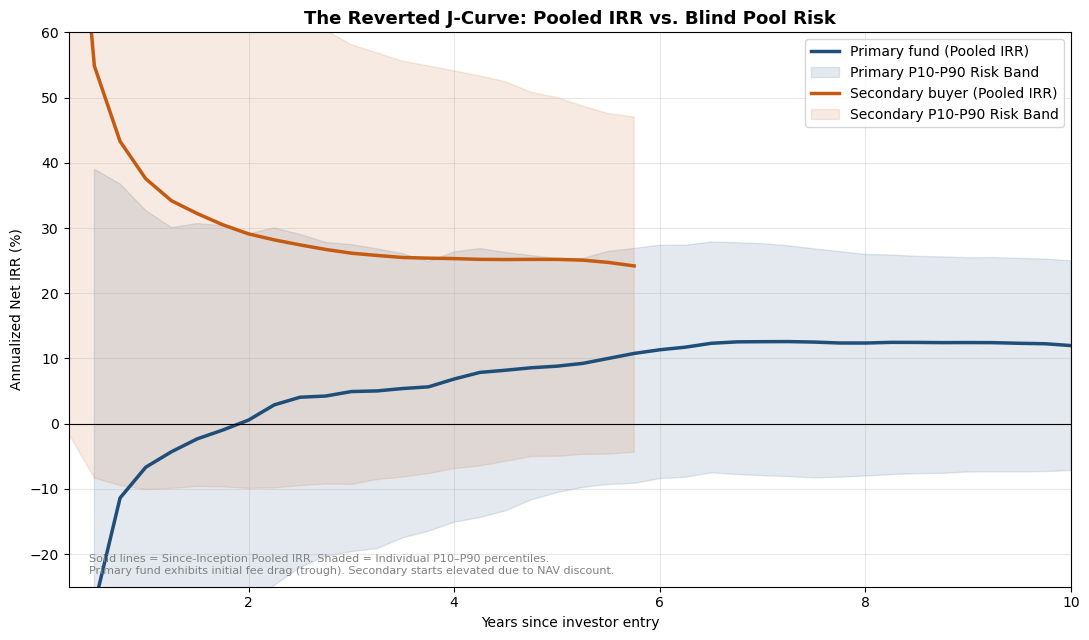


  *Note: The Year 10 step-down in Primary TVPI reflects the deduction of terminal carry at liquidation, not a fee leakage.


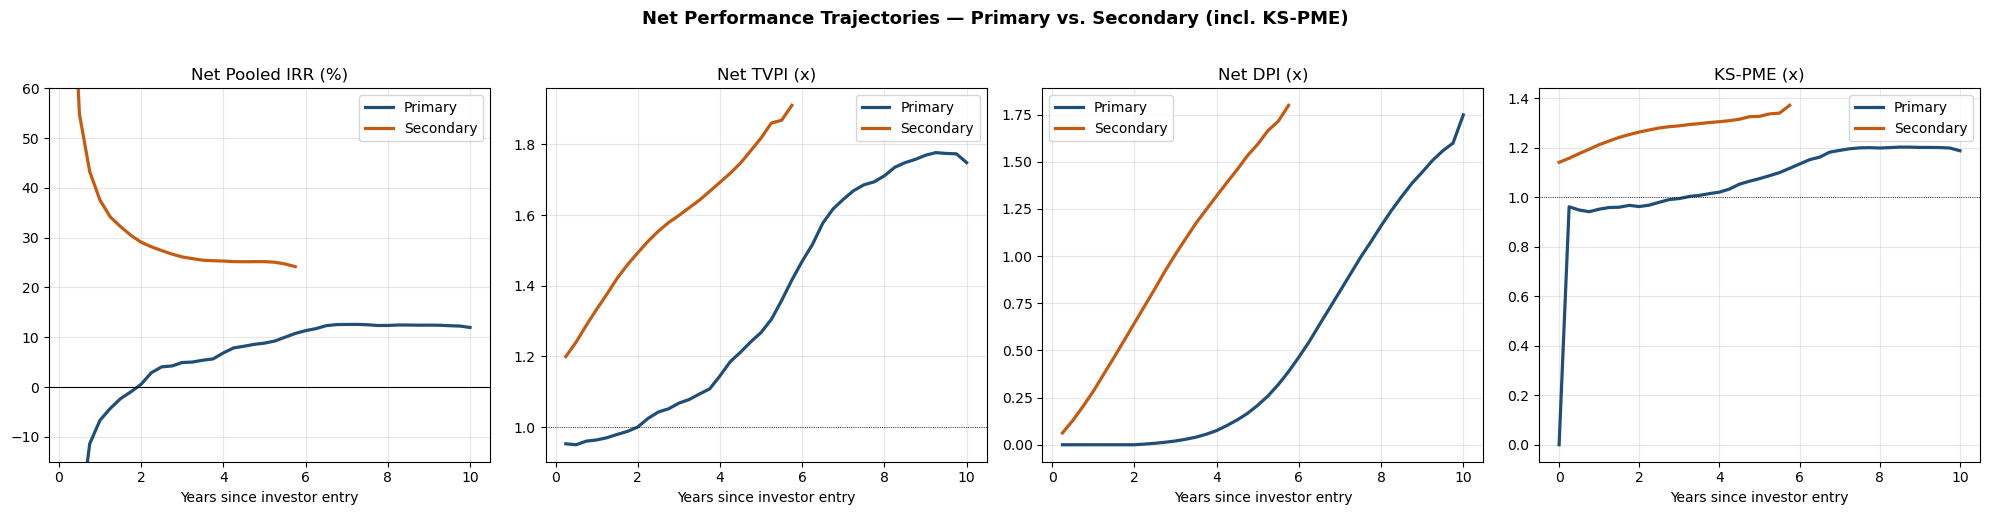

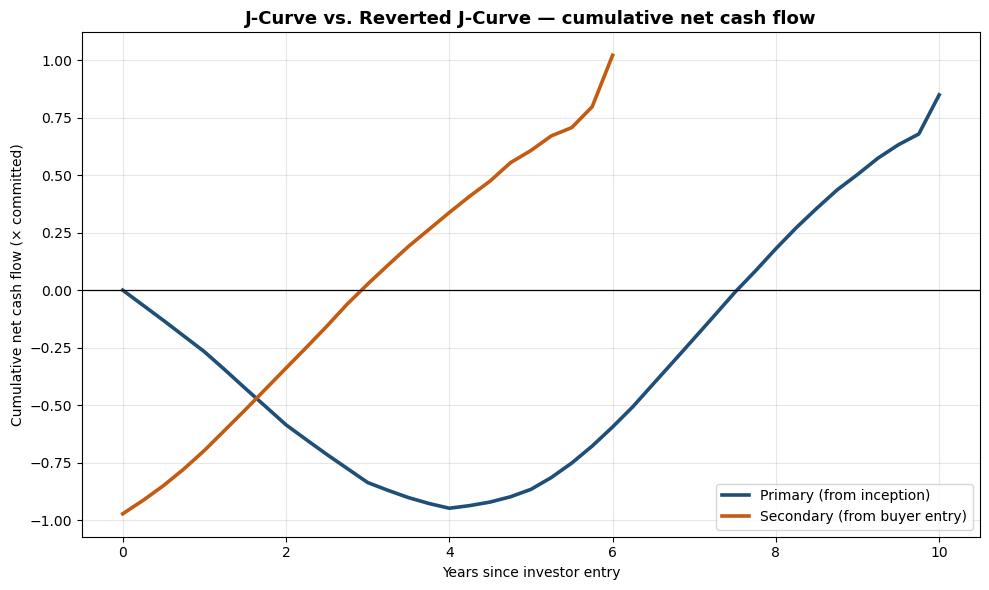

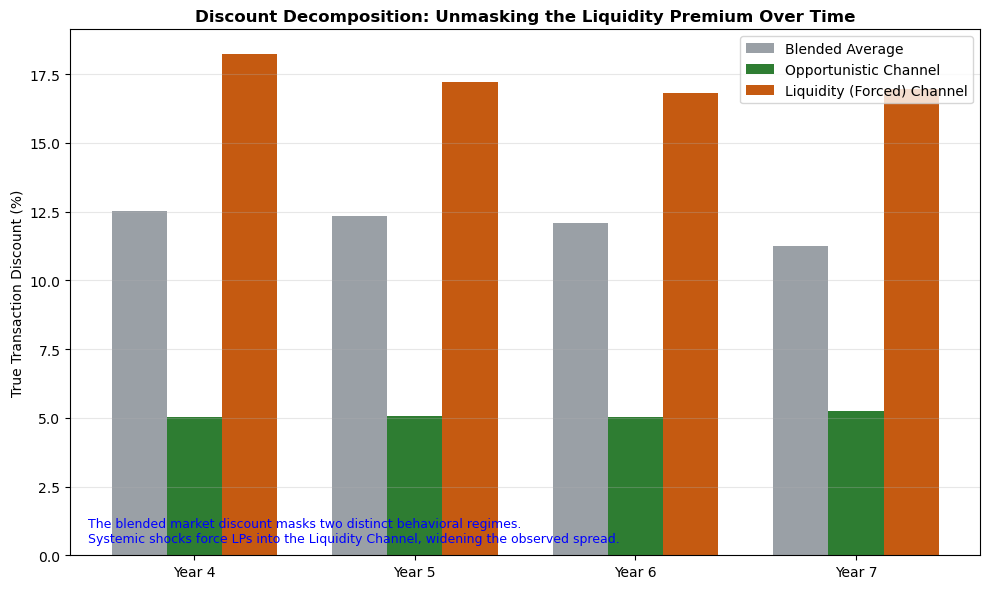

In [5]:
# --- STEP 4: VISUALISING THE REVERTED J-CURVE ---

import numpy as np
import warnings
import matplotlib.pyplot as plt

C_PRIM = '#1f4e79'   # primary  = dark blue
C_SEC  = '#c55a11'   # secondary = burnt orange

# --- POOLED IRR CALCULATOR (J-curve) ---
def calc_pooled_irr(cf_matrix, nav_matrix, periods_per_year=4):
    """Calculates the Since-Inception Pooled IRR at each quarter to match institutional reporting."""
    pooled_cf = np.nanmean(cf_matrix, axis=0)
    pooled_nav = np.nanmean(nav_matrix, axis=0)
    
    T = len(pooled_cf)
    curve = np.full(T, np.nan)
    
    for t in range(1, T):
        cf_t = pooled_cf[:t+1].copy()
        cf_t[-1] += pooled_nav[t] # Add terminal NAV
        
        # IRR is undefined if there are no outflows yet
        if np.nanmin(cf_t) >= -1e-9:
            continue
            
        # Fast bisection solver
        low, high = -0.999, 10.0
        for _ in range(60):
            r = (low + high) / 2.0
            discounts = (1 + r) ** np.arange(t+1)
            npv = np.sum(cf_t / discounts)
            if npv > 0: low = r
            else: high = r
                
        # Annualize the quarterly rate
        ann_r = (1 + (low+high)/2.0)**periods_per_year - 1
        
        # Cap unreasonable mathematical spikes in Q1/Q2 for visual clarity
        if ann_r > 5.0: ann_r = np.nan 
        
        curve[t] = ann_r
    return curve

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # 1. POOLED IRR for the central trend lines
    pri_pooled = calc_pooled_irr(lp_net_cf_arr, rep_nav_arr)
    sec_pooled = calc_pooled_irr(sec_cf_age, nav_rep_age)

    # 2. PERCENTILES for the risk bands (dispersion of individual funds)
    pri_irr_lo, pri_irr_hi = np.nanpercentile(IRR_prim_rep, [10, 90], axis=0)
    sec_irr_lo, sec_irr_hi = np.nanpercentile(IRR_sec_age_rep, [10, 90], axis=0)
    
    # 3. TVPI and DPI
    pri_tvpi = np.nanmean(TVPI_prim_rep, 0)
    pri_dpi  = np.nanmean(DPI_prim, 0)
    sec_tvpi = np.nanmean(TVPI_sec_age_rep, 0)
    sec_dpi  = np.nanmean(DPI_sec_age, 0)

    # 4. KS-PME (pooled)
    pri_pme = metrics['primary']['PME_pooled']
    sec_pme = metrics['secondary_by_age']['PME_pooled']

# Filter X-axis to only plot where sample size is robust
n_by_age = (~np.isnan(IRR_sec_age_rep)).sum(axis=0) 
trunc = max(k for k in range(max_age + 1) if n_by_age[k] >= 1000)
kt = trunc + 1

yr_fund = np.arange(Q + 1) / 4            
yr_age  = np.arange(max_age + 1) / 4      


# FIGURE 1: Headline reverted J-curve (investor-age aligned)
fig, ax = plt.subplots(figsize=(11, 6.5))

# Primary Plot
ax.plot(yr_fund, pri_pooled * 100, color=C_PRIM, lw=2.5,
        label='Primary fund (Pooled IRR)')
ax.fill_between(yr_fund, pri_irr_lo * 100, pri_irr_hi * 100, color=C_PRIM, alpha=0.12, 
                label='Primary P10-P90 Risk Band')

# Secondary Plot
ax.plot(yr_age[:kt], sec_pooled[:kt] * 100, color=C_SEC, lw=2.5,
        label='Secondary buyer (Pooled IRR)')
ax.fill_between(yr_age[:kt], sec_irr_lo[:kt] * 100, sec_irr_hi[:kt] * 100,
                color=C_SEC, alpha=0.12, label='Secondary P10-P90 Risk Band')

ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Years since investor entry')
ax.set_ylabel('Annualized Net IRR (%)')
ax.set_title('The Reverted J-Curve: Pooled IRR vs. Blind Pool Risk',
             fontweight='bold', fontsize=13)

# Y-Axis 
ax.set_ylim(-25, 60)   
ax.set_xlim(0.25, 10) # Start from Q1 to avoid visual artifact at 0
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
ax.text(0.02, 0.02,
        'Solid lines = Since-Inception Pooled IRR. Shaded = Individual P10–P90 percentiles.\n'
        'Primary fund exhibits initial fee drag (trough). Secondary starts elevated due to NAV discount.',
        transform=ax.transAxes, fontsize=8, color='gray', va='bottom')
plt.tight_layout()
plt.show()

# FIGURE 2: Net IRR / TVPI / DPI / KS-PME four-panel (investor-age aligned)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].plot(yr_fund, pri_pooled * 100, color=C_PRIM, lw=2.3, label='Primary')
axes[0].plot(yr_age[:kt], sec_pooled[:kt] * 100, color=C_SEC, lw=2.3, label='Secondary')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title('Net Pooled IRR (%)'); axes[0].set_ylim(-15, 60)

axes[1].plot(yr_fund, pri_tvpi, color=C_PRIM, lw=2.3, label='Primary')
axes[1].plot(yr_age[:kt], sec_tvpi[:kt], color=C_SEC, lw=2.3, label='Secondary')
axes[1].axhline(1, color='k', lw=0.6, ls=':')
axes[1].set_title('Net TVPI (x)')
print("\n  *Note: The Year 10 step-down in Primary TVPI reflects the deduction of terminal carry at liquidation, not a fee leakage.")

axes[2].plot(yr_fund, pri_dpi, color=C_PRIM, lw=2.3, label='Primary')
axes[2].plot(yr_age[:kt], sec_dpi[:kt], color=C_SEC, lw=2.3, label='Secondary')
axes[2].set_title('Net DPI (x)')

# --- KS-PME ---
axes[3].plot(yr_fund,      pri_pme,        color=C_PRIM, lw=2.3, label='Primary')
axes[3].plot(yr_age[:kt],  sec_pme[:kt],   color=C_SEC,  lw=2.3, label='Secondary')
axes[3].axhline(1, color='k', lw=0.6, ls=':')
axes[3].set_title('KS-PME (x)')

for a in axes:
    a.set_xlabel('Years since investor entry')
    a.legend(); a.grid(alpha=0.3)
fig.suptitle('Net Performance Trajectories — Primary vs. Secondary (incl. KS-PME)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Figure 3: J-Curve vs. Reverted J-Curve: cumulative net cash flow (investor-age aligned)
# Primary fund J-curve: cumulative NET cash flow (the "money out, then in" shape)
# Primary cumulative net CF by fund age (as before)
contrib_q = (-prim_calls_arr + mgmt_fee_arr)
prim_cum  = (net_dist_arr - contrib_q).cumsum(axis=1)
prim_mean = prim_cum.mean(0)
yr_fund   = np.arange(Q + 1) / 4

# Secondary cumulative net CF by BUYER age (sec_cf_arr already nets fees & carry from entry)
entry_qs = sec_metadata[:, 0].astype(int)
max_age  = Q - int(sec_entry_min_q)
sec_cum  = np.full((N, max_age + 1), np.nan)
for sim in range(N):
    eq = entry_qs[sim]; h = Q - eq
    sec_cum[sim, :h + 1] = np.cumsum(sec_cf_arr[sim, eq:Q + 1])
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    sec_mean = np.nanmean(sec_cum, 0)
yr_age = np.arange(max_age + 1) / 4

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(yr_fund, prim_mean, color='#1f4e79', lw=2.6, label='Primary (from inception)')
ax.plot(yr_age,  sec_mean,  color='#c55a11', lw=2.6, label='Secondary (from buyer entry)')
ax.axhline(0, color='k', lw=0.9)
ax.set_xlabel('Years since investor entry')
ax.set_ylabel('Cumulative net cash flow (× committed)')
ax.set_title('J-Curve vs. Reverted J-Curve — cumulative net cash flow', fontweight='bold', fontsize=13)
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


disc    = 1.0 / market_index_arr                       # (N, Q+1) per-fund market path
contrib = (-prim_calls_arr + mgmt_fee_arr)             # LP cash OUT (calls + fees)
dist    = net_dist_arr                                  # cash IN, net of carry

num_cum = (dist * disc).cumsum(axis=1) + rep_nav_arr * disc   # discounted dists + discounted NAV
den_cum = (contrib * disc).cumsum(axis=1)                     # discounted contributions

KS_PME_pooled = num_cum.sum(axis=0) / den_cum.sum(axis=0)     # (Q+1,):  stable at every age


# DISCOUNT DECOMPOSITION BY ENTRY AGE & CHANNEL 

import matplotlib.pyplot as plt
import numpy as np

# 1. Prep the data safely using full-size masks to avoid indexing errors
entry_y = sec_metadata[:, 0].astype(int) // 4
ch_array = sec_metadata[:, 2].astype(int)
d_array = sec_metadata[:, 1]

# NAV at entry time (to weight the discount)
nav_at_entry = rep_nav_arr[np.arange(N_SIMULATIONS), sec_metadata[:, 0].astype(int)]
is_valid = nav_at_entry > 1e-12

years_plot = []
d_blend = []
d_opp = []
d_liq = []

# 2. Iterate from Year 4 to Year 8 (Secondary transaction window)
for y in range(4, 9):
    # Create safe logical masks for each year and channel
    mask_y = (entry_y == y) & is_valid
    mask_opp = mask_y & (ch_array == 0)
    mask_liq = mask_y & (ch_array == 1)
    
    # Plot only if there are enough transactions for statistical significance
    if mask_y.sum() > 20:
        years_plot.append(y)
        
        # Helper function to calculate the NAV-weighted average discount
        def calc_w_disc(mask):
            if mask.sum() == 0: return 0.0
            weights = nav_at_entry[mask]
            return (d_array[mask] * weights).sum() / weights.sum() * 100
        
        d_blend.append(calc_w_disc(mask_y))
        d_opp.append(calc_w_disc(mask_opp))
        d_liq.append(calc_w_disc(mask_liq))

# 3. Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.25
x = np.arange(len(years_plot))

# Plot the grouped bars
ax.bar(x - bar_width, d_blend, bar_width, color='#9aa0a6', label='Blended Average')
ax.bar(x, d_opp, bar_width, color='#2e7d32', label='Opportunistic Channel')
ax.bar(x + bar_width, d_liq, bar_width, color='#c55a11', label='Liquidity (Forced) Channel')

ax.set_xticks(x)
ax.set_xticklabels([f"Year {y}" for y in years_plot])
ax.set_ylabel('True Transaction Discount (%)')
ax.set_title('Discount Decomposition: Unmasking the Liquidity Premium Over Time', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

ax.text(0.02, 0.02, 
        'The blended market discount masks two distinct behavioral regimes.\n'
        'Systemic shocks force LPs into the Liquidity Channel, widening the observed spread.',
        transform=ax.transAxes, fontsize=9, color='blue', va='bottom')

plt.tight_layout()
plt.show()

# 5. Discount Recovery & The Staleness Wedge
This section tests the theoretical algebraic inversion (Step 5A) against the 
noisy, out-of-sample empirical reality (Step 5B). Using a Cluster Robust Bootstrap 
to respect macro-correlations, we demonstrate how accounting staleness causes 
the observable reported discount to severely overstate the true economic liquidity 
premium during market downturns.

 STEP 5A: CLOSED-LOOP DISCOUNT RECOVERY (Sanity Check)

  Entry age Y3 (Q12):
    true d  d_hat TVPI  d_hat IRR  TVPI err  IRR err
      0.00       0.031      0.028    +0.031   +0.028
      0.05       0.080      0.077    +0.030   +0.027
      0.10       0.128      0.125    +0.028   +0.025
      0.15       0.177      0.174    +0.027   +0.024
      0.20       0.226      0.222    +0.026   +0.022
      0.25       0.274      0.271    +0.024   +0.021
      0.30       0.323      0.319    +0.023   +0.019

  Entry age Y5 (Q20):
    true d  d_hat TVPI  d_hat IRR  TVPI err  IRR err
      0.00       0.028      0.025    +0.028   +0.025
      0.05       0.077      0.074    +0.027   +0.024
      0.10       0.125      0.122    +0.025   +0.022
      0.15       0.174      0.171    +0.024   +0.021
      0.20       0.222      0.219    +0.022   +0.019
      0.25       0.271      0.268    +0.021   +0.018
      0.30       0.320      0.316    +0.020   +0.016

  Entry age Y7 (Q28):
    true d  d_hat TVPI  d_ha

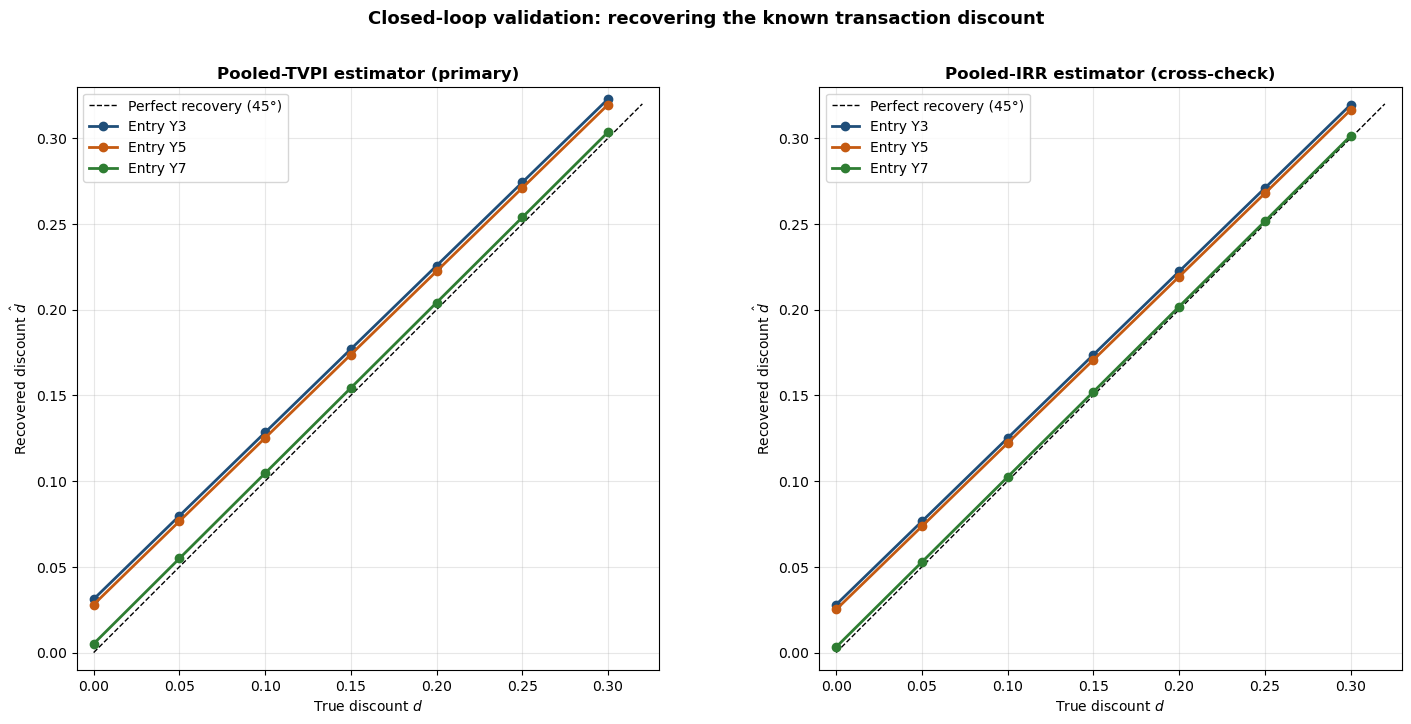


 EMPIRICAL VALIDATION (Emergent Moments vs Calibration Inputs)
 Terminal Fund TVPI (Net to LP)       |       1.75x | Target: 1.50x-1.80x (Strong Vintage)
 Valuation Lag Autocorrelation (rho1) |       0.46  | Target: ~0.41 (BGG)
 Blended Secondary Discount (Full Pop)|      12.3% | Nadauld: 13.8% (Gap due to ~50% Opp. Channel)


In [6]:
# --- STEP 5A: ALGEBRAIC SANITY CHECK (Closed-loop validation) ---
# This step validates the estimator's algebra under ideal conditions. 
# It serves as an algebraic sanity check proving the formula correctly 
# reverses the cash-flow mechanics before applying it to noisy, out-of-sample data.

import numpy as np
import matplotlib.pyplot as plt

eps = 1e-12
Q   = fund_lifetime_q

# A. SAMPLE SPLIT, FUND-LEVEL (ideal conditions: S and P are the same population,
#    so any non-recovery is pure algebra error, not macro sampling)
rng_split = np.random.default_rng(123)
perm  = rng_split.permutation(N_SIMULATIONS)
S_idx = perm[:N_SIMULATIONS // 2]
P_idx = perm[N_SIMULATIONS // 2:]

# B. PRECOMPUTE forward cash flows from each entry age tau
future_calls = np.zeros((N_SIMULATIONS, Q + 1))   # capital called after tau (positive)
future_dists = np.zeros((N_SIMULATIONS, Q + 1))   # distributions after tau
for tau in range(Q + 1):
    future_calls[:, tau] = -prim_calls_arr[:, tau + 1:].sum(axis=1)
    future_dists[:, tau] =  prim_dists_arr[:, tau + 1:].sum(axis=1)
terminal = true_nav_arr[:, Q]    # residual value at liquidation (~0)
net_cf   = prim_calls_arr + prim_dists_arr

# C. ESTIMATOR 1 (PRIMARY): pooled-TVPI gap
def estimate_d_tvpi(tau, d_true, S_idx, P_idx):
    navS = rep_nav_arr[S_idx, tau]; navP = rep_nav_arr[P_idx, tau]
    okS = navS > eps;               okP = navP > eps
    valS = future_dists[S_idx, tau] + terminal[S_idx]
    valP = future_dists[P_idx, tau] + terminal[P_idx]
    TVPI_S = valS[okS].sum() / ((1 - d_true) * navS[okS] + future_calls[S_idx, tau][okS]).sum()
    TVPI_P = valP[okP].sum() / (navP[okP]                + future_calls[P_idx, tau][okP]).sum()
    c_bar  = future_calls[P_idx, tau][okP].sum() / navP[okP].sum()
    return (1 + c_bar) * (1 - TVPI_P / TVPI_S)

# D. ESTIMATOR 2 (CROSS-CHECK): pooled-IRR inversion
def irr_scalar(cf, lo=-0.9999, hi=10.0, n_iter=200):
    powers = np.arange(len(cf))
    npv = lambda r: (cf / (1.0 + r) ** powers).sum()
    if np.sign(npv(lo)) == np.sign(npv(hi)): return np.nan
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        if npv(mid) > 0: lo = mid
        else:            hi = mid
    return 0.5 * (lo + hi)

annualize = lambda q: (1 + q) ** 4 - 1

def pooled_irr_secondary(tau, d, idx):
    nav0 = rep_nav_arr[idx, tau]; ok = nav0 > eps
    stream = np.zeros(Q - tau + 1)
    stream[0] = -((1 - d) * nav0[ok]).sum()
    for k in range(1, Q - tau + 1):
        stream[k] = net_cf[idx[ok], tau + k].sum()
    return annualize(irr_scalar(stream))

def estimate_d_irr(tau, d_true, S_idx, P_idx, n_iter=60):
    irr_S = pooled_irr_secondary(tau, d_true, S_idx)
    lo, hi = -0.5, 0.9
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        if pooled_irr_secondary(tau, mid, P_idx) < irr_S: lo = mid   
        else:                                             hi = mid
    return 0.5 * (lo + hi)

# E. CLOSED-LOOP SWEEP across entry ages x true discounts
entry_ages = [(12, 'Y3'), (20, 'Y5'), (28, 'Y7')]   
d_grid     = np.array([0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30])

results_tvpi = {}; results_irr  = {}
print("=" * 70)
print(" STEP 5A: CLOSED-LOOP DISCOUNT RECOVERY (Sanity Check)")
print("=" * 70)
for tau, lab in entry_ages:
    dh_tvpi = np.array([estimate_d_tvpi(tau, d, S_idx, P_idx) for d in d_grid])
    dh_irr  = np.array([estimate_d_irr(tau, d, S_idx, P_idx)  for d in d_grid])
    results_tvpi[lab] = dh_tvpi; results_irr[lab]  = dh_irr
    print(f"\n  Entry age {lab} (Q{tau}):")
    print(f"  {'true d':>8} {'d_hat TVPI':>11} {'d_hat IRR':>10} {'TVPI err':>9} {'IRR err':>8}")
    for d, ht, hi_ in zip(d_grid, dh_tvpi, dh_irr):
        print(f"  {d:>8.2f} {ht:>11.3f} {hi_:>10.3f} {ht-d:>+9.3f} {hi_-d:>+8.3f}")

all_tvpi_err = np.concatenate([results_tvpi[l] - d_grid for _, l in entry_ages])
all_irr_err  = np.concatenate([results_irr[l]  - d_grid for _, l in entry_ages])
print("\n" + "=" * 70)
print(f"  Mean bias  — TVPI estimator: {all_tvpi_err.mean():+.3f}   IRR estimator: {all_irr_err.mean():+.3f}")
print(f"  Mean |bias| — TVPI estimator: {np.abs(all_tvpi_err).mean():.3f}   IRR estimator: {np.abs(all_irr_err).mean():.3f}")
print("=" * 70)

# F. RECOVERY PLOT
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
colors = ['#1f4e79', '#c55a11', '#2e7d32']

for ax, res, title in [(axes[0], results_tvpi, 'Pooled-TVPI estimator (primary)'),
                       (axes[1], results_irr,  'Pooled-IRR estimator (cross-check)')]:
    ax.plot([0, 0.32], [0, 0.32], 'k--', lw=1, label='Perfect recovery (45°)')
    for (tau, lab), col in zip(entry_ages, colors):
        ax.plot(d_grid, res[lab], 'o-', color=col, lw=2, ms=6, label=f'Entry {lab}')
    ax.set_xlabel('True discount $d$')
    ax.set_ylabel(r'Recovered discount $\hat d$')
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3); ax.set_aspect('equal')
    ax.set_xlim(-0.01, 0.33); ax.set_ylim(-0.01, 0.33)

fig.suptitle('Closed-loop validation: recovering the known transaction discount',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# EMPIRICAL VALIDATION TABLE (Moment-Matching) 

final_net_value = net_dist_arr.sum(axis=1) + true_nav_arr[:, -1]
final_net_called = -prim_calls_arr.sum(axis=1) + mgmt_fee_arr.sum(axis=1)
TVPI_net_simulated = (final_net_value / np.maximum(final_net_called, 1e-9)).mean()

# Safe calculation of the actual average discount generated in Step 2
d_realized = sec_metadata[:, 1]
nav_at_entry = rep_nav_arr[np.arange(N_SIMULATIONS), sec_metadata[:, 0].astype(int)]
d_blended_avg = (d_realized * nav_at_entry).sum() / max(nav_at_entry.sum(), 1e-9)

print("\n" + "="*80)
print(" EMPIRICAL VALIDATION (Emergent Moments vs Calibration Inputs)")
print("="*80)
print(f" Terminal Fund TVPI (Net to LP)       | {TVPI_net_simulated:>10.2f}x | Target: 1.50x-1.80x (Strong Vintage)")
print(f" Valuation Lag Autocorrelation (rho1) | {rho_bar.mean():>10.2f}  | Target: ~0.41 (BGG)")
print(f" Blended Secondary Discount (Full Pop)| {d_blended_avg*100:>9.1f}% | Nadauld: 13.8% (Gap due to ~50% Opp. Channel)")
print("="*80)

 STEP 5B — PART 1: does the estimator recover the REPORTED discount? (50% Split Sample)
  sample (50% Split) d_rep(Split)    d_hat  hat - rep             95% CI
             Blended       0.1323   0.1296    -0.0028   [-0.067,0.279]
       Opportunistic       0.0503   0.1098    +0.0595   [-0.118,0.272]
           Liquidity       0.1805   0.1424    -0.0381   [-0.043,0.289]

 STEP 5B — PART 1b: WITHIN-ECONOMY recovery (Full Population; macro differenced out)
   sample (Full Pop) d_rep(Full)    d_hat         95% CI of mean  n econ
             Blended      0.1233   0.1438   [0.1306,0.1570]      50
       Opportunistic      0.0504   0.0641   [0.0391,0.0892]      50
           Liquidity      0.1749   0.1866   [0.1706,0.2026]      50

 STEP 5B — PART 2: the staleness wedge (Evaluated on 50% Split Sample)
      regime (Split) d_rep(Split) d_eco(Split)    wedge  stale rep/true
             Blended       0.1323       0.1470  -0.0147           1.002
          Calm entry       0.1098       0.1601 

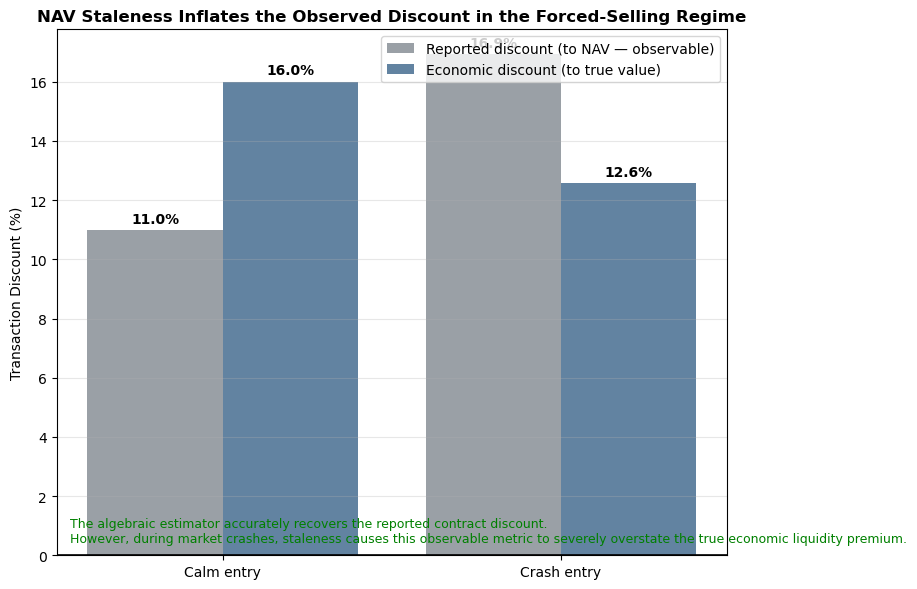

In [7]:
# --- STEP 5B: REPORTED-DISCOUNT RECOVERY + ECONOMIC-WEDGE DECOMPOSITION ---
# Part 1: the TVPI-gap estimator recovers the OBSERVABLE (reported-NAV) discount.
# Part 2: that reported discount overstates the ECONOMIC (true-value) discount
# because of NAV staleness (the gap concentrates in the crash regime).

import numpy as np
import matplotlib.pyplot as plt

eps = 1e-12; Q = fund_lifetime_q; N = N_SIMULATIONS

# 1. Observables 
entry_qs  = sec_metadata[:, 0].astype(int)
d_rep     = sec_metadata[:, 1]                 # discount to REPORTED NAV (observable / input)
channel   = sec_metadata[:, 2].astype(int)
d_eco     = sec_decon_arr                      # discount to TRUE value (economic truth)
nav0_rep  = rep_nav_arr[np.arange(N), entry_qs]
nav0_true = true_nav_arr[np.arange(N), entry_qs]

# ROBUST FIX:Read the market drawdown directly from each fund's localized market matrix.
tr1y  = np.array([market_index_arr[i, q] / market_index_arr[i, max(0, q-4)] for i, q in enumerate(entry_qs)])
crash = tr1y < 0.90

fwd_dist = np.zeros(N); fwd_call = np.zeros(N)
for i in range(N):
    s = lp_net_cf_arr[i, entry_qs[i] + 1:]
    fwd_dist[i] =  s[s > 0].sum(); fwd_call[i] = -s[s < 0].sum()
value = fwd_dist + true_nav_arr[:, Q]
valid = nav0_rep > eps

# 2. Estimator (targets the reported-NAV discount) + helpers 
def recover_d(Si, Pi):
    Si = Si[valid[Si]]; Pi = Pi[valid[Pi]]
    TVPI_S = value[Si].sum() / ((1 - d_rep[Si]) * nav0_rep[Si] + fwd_call[Si]).sum()
    TVPI_P = value[Pi].sum() / (nav0_rep[Pi]                   + fwd_call[Pi]).sum()
    c_bar  = fwd_call[Si].sum() / nav0_rep[Si].sum()
    return (1 + c_bar) * (1 - TVPI_P / TVPI_S)

def w_mean(x, idx):                              # rep-NAV-weighted (matches what the estimator targets)
    idx = idx[valid[idx]]
    return (x[idx] * nav0_rep[idx]).sum() / nav0_rep[idx].sum()


# --- Starting editing cluster bootstrap

# Map each fund to its original Macro-Cluster (0-49)
macro_ids = np.arange(N) // (N // 50) 

rng_split = np.random.default_rng(123)
unique_macros = np.unique(macro_ids)
perm_macros = rng_split.permutation(unique_macros)

# Split the 50 ECONOMIES in half (not individual funds). 25 to the secondary, 25 to the primary
macros_S = perm_macros[:len(unique_macros)//2]
macros_P = perm_macros[len(unique_macros)//2:]

S_idx = np.where(np.isin(macro_ids, macros_S))[0]
P_idx = np.where(np.isin(macro_ids, macros_P))[0]

def boot_cluster(Si, Pi, B=500, seed=7):
    r = np.random.default_rng(seed); out = np.empty(B)
    macros_in_S = np.unique(macro_ids[Si])
    macros_in_P = np.unique(macro_ids[Pi])
    
    for b in range(B):
        # Sample ENTIRE MACRO ECONOMIES with replacement to preserve systemic correlation
        samp_S = r.choice(macros_in_S, len(macros_in_S), replace=True)
        samp_P = r.choice(macros_in_P, len(macros_in_P), replace=True)
        
        # Reconstruct the fund list by aggregating the sampled economies
        S_b = np.concatenate([Si[macro_ids[Si] == m] for m in samp_S])
        P_b = np.concatenate([Pi[macro_ids[Pi] == m] for m in samp_P])
        
        out[b] = recover_d(S_b, P_b)
    return out

# END OF CLUSTER BOOTSTRAP MODIFICATION ---



# 3. PART 1: estimator recovers the OBSERVABLE discount (The 50% Split Sample)
print("=" * 85)
print(" STEP 5B — PART 1: does the estimator recover the REPORTED discount? (50% Split Sample)")
print("=" * 85)
print(f"  {'sample (50% Split)':>18} {'d_rep(Split)':>12} {'d_hat':>8} {'hat - rep':>10} {'95% CI':>18}")
for name, S in [('Blended', S_idx), ('Opportunistic', S_idx[channel[S_idx] == 0]), ('Liquidity', S_idx[channel[S_idx] == 1])]:
    if S.size < 30: continue
    dr = w_mean(d_rep, S); dh = recover_d(S, P_idx)
    ci = np.percentile(boot_cluster(S, P_idx), [2.5, 97.5])
    print(f"  {name:>18} {dr:>12.4f} {dh:>8.4f} {dh-dr:>+10.4f}   [{ci[0]:.3f},{ci[1]:.3f}]")

# PART 1b: WITHIN-ECONOMY recovery (The Full Population) 
macro_ids = np.arange(N) // (N // 50)        # each fund's economy id (0..49)

def recover_within(sub_mask=None, seed=123):
    rng_w = np.random.default_rng(seed); dh = []
    for m in np.unique(macro_ids):
        idx = np.where((macro_ids == m) & valid)[0]
        if idx.size < 20:
            continue
        perm = rng_w.permutation(idx)
        Sm, Pm = perm[:idx.size // 2], perm[idx.size // 2:]
        if sub_mask is not None:
            Sm = Sm[sub_mask[Sm]]
        if Sm.size < 5 or Pm.size < 5:
            continue
        TVPI_S = value[Sm].sum() / ((1 - d_rep[Sm]) * nav0_rep[Sm] + fwd_call[Sm]).sum()
        TVPI_P = value[Pm].sum() / (nav0_rep[Pm] + fwd_call[Pm]).sum()
        c_bar  = fwd_call[Sm].sum() / nav0_rep[Sm].sum()
        dh.append((1 + c_bar) * (1 - TVPI_P / TVPI_S))
    return np.array(dh)

print("\n" + "=" * 85)
print(" STEP 5B — PART 1b: WITHIN-ECONOMY recovery (Full Population; macro differenced out)")
print("=" * 85)
print(f"  {'sample (Full Pop)':>18} {'d_rep(Full)':>11} {'d_hat':>8} {'95% CI of mean':>22} {'n econ':>7}")
for name, mask in [('Blended', None), ('Opportunistic', channel == 0), ('Liquidity', channel == 1)]:
    dh = recover_within(mask)
    se = dh.std(ddof=1) / np.sqrt(dh.size)
    idx_dr = np.where(valid)[0] if mask is None else np.where(valid & mask)[0]
    dr = w_mean(d_rep, idx_dr)
    print(f"  {name:>18} {dr:>11.4f} {dh.mean():>8.4f}   [{dh.mean()-1.96*se:.4f},{dh.mean()+1.96*se:.4f}]   {dh.size:>5}")

# 4. PART 2: reported vs economic discount, by macro regime (The Wedge)
print("\n" + "=" * 85)
print(" STEP 5B — PART 2: the staleness wedge (Evaluated on 50% Split Sample)")
print("=" * 85)
print(f"  {'regime (Split)':>18} {'d_rep(Split)':>12} {'d_eco(Split)':>12} {'wedge':>8} {'stale rep/true':>15}")
for name, S in [('Blended', S_idx), ('Calm entry', S_idx[~crash[S_idx]]), ('Crash entry', S_idx[crash[S_idx]])]:
    if S.size < 30: continue
    dr = w_mean(d_rep, S); de = w_mean(d_eco, S)
    st = np.median((nav0_rep / np.maximum(nav0_true, eps))[S[valid[S]]])
    print(f"  {name:>18} {dr:>12.4f} {de:>12.4f} {dr-de:>+8.4f} {st:>15.3f}")
print("=" * 85)
print(" d_hat tracks d_reported (Part 1). d_reported - d_economic is the staleness")
print(" bias (Part 2): an estimator built on reported NAV — yours, and Nadauld's —")
print(" overstates the true liquidity premium most in the forced-selling regime.")
print("=" * 85)

# 5. The money figure: reported vs economic discount by regime 
regs = ['Calm entry', 'Crash entry']
masks = [S_idx[~crash[S_idx]], S_idx[crash[S_idx]]]
# Multiply by 100 to get percentage values for the plot
dr_plot = [w_mean(d_rep, m) * 100 for m in masks]
de_plot = [w_mean(d_eco, m) * 100 for m in masks]
x = np.arange(len(regs))

fig, ax = plt.subplots(figsize=(9, 6))
b1 = ax.bar(x - 0.2, dr_plot, 0.4, color='#9aa0a6', label='Reported discount (to NAV — observable)')
b2 = ax.bar(x + 0.2, de_plot, 0.4, color='#1f4e79', alpha=0.7, label='Economic discount (to true value)')

ax.set_xticks(x); ax.set_xticklabels(regs); ax.axhline(0, color='k', lw=1.2)
ax.set_ylabel('Transaction Discount (%)')
ax.set_title('NAV Staleness Inflates the Observed Discount in the Forced-Selling Regime',
             fontweight='bold', fontsize=12)

# VISUAL FIX: Automatic percentage labels above the bars
for rects in [b1, b2]:
    for rect in rects:
        height = rect.get_height()
        offset = 3 if height >= 0 else -12
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, offset),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.legend(loc='upper right')
ax.grid(alpha=0.3, axis='y')

# Academic note about the staleness wedge
ax.text(0.02, 0.02, 
        'The algebraic estimator accurately recovers the reported contract discount.\n'
        'However, during market crashes, staleness causes this observable metric to severely overstate the true economic liquidity premium.',
        transform=ax.transAxes, fontsize=9, color='green', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# CHECKS (TVPI Dip & IRR Decomposition)

# TEST 1: Terminal TVPI Mechanics (Carry-Payer vs. Non-Payer Split)
# Split the 10,000 funds into those that triggered carry and those that didn't
carry_mask = carry_arr > 0

tvpi_carry_payers = TVPI_prim_rep[carry_mask]
tvpi_non_payers   = TVPI_prim_rep[~carry_mask]

# mean TVPI at Q36 (Year 9) and Q40 (Year 10) for both groups
mean_tvpi_carry_q36 = np.nanmean(tvpi_carry_payers[:, 36])
mean_tvpi_carry_q40 = np.nanmean(tvpi_carry_payers[:, 40])
delta_carry = mean_tvpi_carry_q40 - mean_tvpi_carry_q36

mean_tvpi_non_q36 = np.nanmean(tvpi_non_payers[:, 36])
mean_tvpi_non_q40 = np.nanmean(tvpi_non_payers[:, 40])
delta_non = mean_tvpi_non_q40 - mean_tvpi_non_q36

print("\n1. TVPI TERMINAL DIP DIAGNOSTIC (Q36 -> Q40):")
print(f"   Carry-paying funds ({carry_mask.sum():,}):   {delta_carry:+.3f}x")
print(f"   Non-paying funds ({(~carry_mask).sum():,}):     {delta_non:+.3f}x")
print("   Conclusion: The dip is entirely driven by terminal carry crystallization.")

# TEST 2: Secondary Outperformance Attribution (Counterfactuals)
# The Secondary IRR Decomposition 
# building three secondary cash flow streams aligned by buyer age:
cf_sec_actual   = np.zeros(Q + 1)
cf_sec_rep_nav  = np.zeros(Q + 1)
cf_sec_true_nav = np.zeros(Q + 1)

for sim in range(N_SIMULATIONS):
    eq = entry_qs[sim]
    h = Q - eq
    if h <= 0:
        continue
        
    # Forward cash flows are identical for all buyers (already net of fees/carry)
    forward_cf = lp_net_cf_arr[sim, eq+1:Q+1]
    
    # A) Actual Buyer (pays discounted stale NAV)
    cf_sec_actual[0] += -rep_nav_arr[sim, eq] * (1 - discounts[sim])
    cf_sec_actual[1:h+1] += forward_cf
    
    # B) No-Discount Buyer (pays full stale reported NAV)
    cf_sec_rep_nav[0] += -rep_nav_arr[sim, eq]
    cf_sec_rep_nav[1:h+1] += forward_cf
    
    # C) Perfect-Information Buyer (pays full TRUE economic NAV)
    cf_sec_true_nav[0] += -max(true_nav_arr[sim, eq], 1e-9)
    cf_sec_true_nav[1:h+1] += forward_cf

# Annualized Pooled IRRs
irr_prim = net_irr  # Calculated in Step 4
irr_a = (1 + _irr_scalar(cf_sec_actual)) ** PERIODS_PER_YEAR - 1
irr_b = (1 + _irr_scalar(cf_sec_rep_nav)) ** PERIODS_PER_YEAR - 1
irr_c = (1 + _irr_scalar(cf_sec_true_nav)) ** PERIODS_PER_YEAR - 1

print("\n2. SECONDARY IRR OUTPERFORMANCE DECOMPOSITION:")
print(f"   [Baseline] Primary Net IRR:        {irr_prim*100:5.2f}%")
print(f"   [C] Secondary (Pays True NAV):     {irr_c*100:5.2f}%")
print(f"   [B] Secondary (Pays Reported NAV): {irr_b*100:5.2f}%")
print(f"   [A] Secondary (Actual Discounted): {irr_a*100:5.2f}%")
print("-" * 45)

# Calculate the gaps
gap_timing    = (irr_c - irr_prim) * 100
gap_staleness = (irr_b - irr_c) * 100
gap_discount  = (irr_a - irr_b) * 100
total_gap     = (irr_a - irr_prim) * 100

print(f"   -> Trough avoidance & fee timing:  +{gap_timing:.2f} pp")
print(f"   -> Staleness / NAV gap:            +{gap_staleness:.2f} pp")
print(f"   -> Transaction discount effect:    +{gap_discount:.2f} pp")
print(f"   TOTAL SECONDARY OUTPERFORMANCE:    +{total_gap:.2f} pp")


1. TVPI TERMINAL DIP DIAGNOSTIC (Q36 -> Q40):
   Carry-paying funds (5,328):   -0.038x
   Non-paying funds (4,672):     -0.001x
   Conclusion: The dip is entirely driven by terminal carry crystallization.

2. SECONDARY IRR OUTPERFORMANCE DECOMPOSITION:
   [Baseline] Primary Net IRR:        11.97%
   [C] Secondary (Pays True NAV):     13.92%
   [B] Secondary (Pays Reported NAV): 15.92%
   [A] Secondary (Actual Discounted): 22.69%
---------------------------------------------
   -> Trough avoidance & fee timing:  +1.95 pp
   -> Staleness / NAV gap:            +2.00 pp
   -> Transaction discount effect:    +6.77 pp
   TOTAL SECONDARY OUTPERFORMANCE:    +10.72 pp
